# PCA signature scoring

**PCA 基因签名评分**

Score the public IMvigor210 demonstration matrix (872 features × 348 samples). This is a restricted feature panel, not a complete transcriptome; only signatures with sufficient overlap are returned.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
expression = load("imvigor210_eset")
input_shape = expression.shape
display(expression.iloc[:5, :4])


,SAMf2ce197162ce,SAM698d8d76b934,SAMc1b27bc16435,SAM85e41e7f33f9
rownames,,,,
LOC100093631,3.100940,2.820764,3.705899,2.810128
LOC100126784,-2.623775,-4.256052,-5.410445,-2.076004
LOC100128108,-1.501784,0.520052,-0.766588,-2.076004
LOC100128288,-0.336198,-1.220428,-1.951013,-1.258868
LOC100128361,0.254547,0.292385,-0.200991,-0.025377


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.calculate_sig_score(expression, "signature_collection", method="pca", mini_gene_count=3, adjust_eset=True, n_threads=8)
elapsed = perf_counter() - started
display(save_result(result, "03_signature_pca", elapsed, input_shape))

Completed in 0.733 s; input 872 features × 348 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,03_signature_pca,0.732903,"[872, 348]","{'result': [348, 60]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,ID,CD_8_T_effector,DDR,APM,Immune_Checkpoint,CellCycle_Reg,Pan_F_TBRs,Histones,EMT1,EMT2,...,CD4_c1_Treg,CD4_c3_Tfh,CD4_c4_Tstr,CD4_c5_CTL,CD4_c7_Tn_TCEA3,CD8_c1_Tex,CD8_c2_Teff,CD8_c4_Tstr,Mph_04_TREM2,TMEscore_CIR
0,SAMf2ce197162ce,-1.584367,1.346774,-0.979769,-0.477971,1.605590,3.093213,0.069053,1.066880,2.198742,...,-0.081692,-0.588957,-1.049290,-0.458078,0.314556,-0.997344,-0.238462,-1.049290,-0.290213,-3.413673
1,SAM698d8d76b934,-0.106237,6.119335,0.554620,0.431672,1.703881,-0.571979,1.155106,1.543544,0.567396,...,-0.306774,0.432561,1.246470,-0.486190,0.238363,0.533455,-1.034561,1.246470,0.637334,1.027188
2,SAMc1b27bc16435,1.341304,4.050033,-0.938559,-0.087938,0.736582,-1.100018,1.608123,-0.652714,-1.589814,...,0.971056,0.302289,0.366334,0.869520,-0.397728,0.920114,0.503006,0.366334,-0.315272,1.898111
3,SAM85e41e7f33f9,2.503446,2.963588,1.014846,1.783894,1.333749,2.179296,1.470087,0.439613,2.723838,...,0.843372,1.381372,0.719952,2.064320,1.382598,2.597523,1.171392,0.719952,1.462149,0.656031
4,SAMf275eb859a39,0.338467,-3.981383,0.841926,-0.304024,-2.189340,-3.066415,-2.128893,-1.621112,-2.652536,...,0.097016,-0.526341,-0.431028,0.424791,0.218402,-0.131068,-0.324176,-0.431028,-0.057872,2.605920


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Heatmap z-scores are display-only; exported result tables keep the original values. `S01`, `S02`, … follow the sample order of each displayed matrix; the mapping is printed below.

For the IMvigor210 heatmaps, only the first 30 samples are shown (24 per panel in the integration notebook); scoring and distributions use all 348.

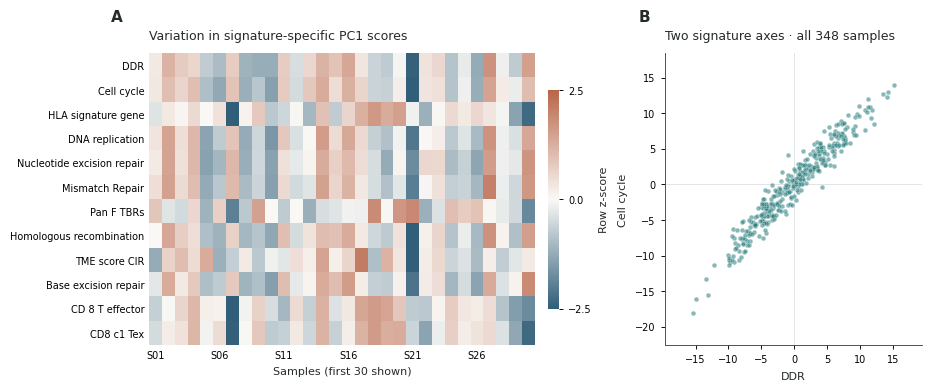

In [5]:
scores = numeric_scores(result).astype(float)
features = scores.std().nlargest(12).index
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), gridspec_kw={"width_ratios": [1.5, 1]}, layout="constrained")
heatmap(axes[0], scores[features].T)
x, y = features[:2]
scatter(axes[1], scores[x], scores[y], *clean_labels([x, y]))
axes[1].axhline(0, color="#DDE1E2", linewidth=0.6, zorder=0)
axes[1].axvline(0, color="#DDE1E2", linewidth=0.6, zorder=0)
panel(axes[0], "A", "Variation in signature-specific PC1 scores")
panel(axes[1], "B", "Two signature axes · all 348 samples")
save_figure(fig, '03_signature_pca')


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,SAMf2ce197162ce
1,S02,SAM698d8d76b934
2,S03,SAMc1b27bc16435
3,S04,SAM85e41e7f33f9
4,S05,SAMf275eb859a39
5,S06,SAM7f0d9cc7f001
6,S07,SAM4305ab968b90
7,S08,SAMcf018fee2acd
8,S09,SAMb2f1d0e54ece
9,S10,SAMcc4675f394a1


## 4. Interpretation and limits / 解读与边界

Each signature gets its own PC1 across samples; this is not a single global PCA embedding. PC1 direction is aligned to mean expression as in IOBRpy. Scores from different signatures can have different scales.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/03_signature_pca.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.